# 64-rank fio read statistics (Aurora / DAOS)

Aggregates per-rank fio JSON output (one file per MPI rank; rank files may
carry a non-JSON MPI/PBS header line, so parsing starts at the first `{`).

Two aggregate throughput metrics are used throughout:

- **wall GiB/s** — total bytes / max rank runtime (wall-clock view, bounded by the slowest rank)
- **aggregate GiB/s** — sum of every rank's own `bw_bytes` (optimistic; ignores rank skew)

The 10 TiB `n20_ppn32` job folders in this directory are 640-rank runs and are
**not** covered here. Future sections (e.g. reading 1 TiB of 4 MiB files) will
be appended below Section 1 and can reuse the helpers from the setup cell.

# Section 1 — 1 TiB reads, 16 GiB/rank files (`fs16g`)

64 ranks x 16 GiB = 1 TiB per pass. Job families:
`{read,randread}_(1tib|fio-1tib-fs16g)_{n2_ppn32,n4_ppn16,n8_ppn8}_bs2m_iod16_<jobid>`.
Most jobs are a single cold pass (`iter01`, or untagged for the oldest job);
two n2_ppn32 jobs repeat the pass 9-10 times.

1. **Sanity check** — every rank read exactly 16 GiB; every pass totals 1 TiB.
2. **Time-series** — per-iteration throughput for the repeated-read jobs.
3. **Layout sweep** — throughput vs n x ppn (first/cold iteration per job, median across repeated jobs).
4. **Per-rank by host** — per-rank bandwidth grouped by compute node (layouts in `BYHOST_NODES`).

In [1]:
import json
import re
import statistics as st
from collections import defaultdict
from pathlib import Path

GiB = 1024**3

def load_fio_json(path):
    """Parse a fio JSON file, skipping any non-JSON header lines."""
    txt = Path(path).read_text()
    return json.loads(txt[txt.index("{"):])

def scan_rank_file(path):
    """One rank's fio JSON -> (io_bytes, bw_bytes, runtime_ms) over its jobs."""
    d = load_fio_json(path)
    return (sum(j["read"]["io_bytes"] for j in d["jobs"]),
            sum(j["read"]["bw_bytes"] for j in d["jobs"]),
            max(j["read"]["runtime"] for j in d["jobs"]))

# --- discover the fs16g 1 TiB job folders (both naming generations) ---
FS16G_JOB_RE = re.compile(r"^(?P<pattern>read|randread)_(?:1tib|fio-1tib-fs16g)_"
                          r"n(?P<nodes>\d+)_ppn(?P<ppn>\d+)_.*_(?P<jobid>\d+)$")

fs16g_jobs = {}                    # folder name -> {pattern, nodes, ppn, jobid}
fs16g_passes = defaultdict(list)   # (folder, iter tag) -> [rank file paths]
for d in sorted(Path(".").iterdir()):
    m = FS16G_JOB_RE.match(d.name) if d.is_dir() else None
    if not m:
        continue
    fs16g_jobs[d.name] = m.groupdict()
    for fp in sorted(d.glob("*.json")):
        mi = re.search(r"iter(\d+)", fp.name)
        # untagged files (oldest single-pass job) fall into the "-" group
        fs16g_passes[(d.name, mi.group(1) if mi else "-")].append(fp)

# --- scan every rank file once; everything below reuses this cache ---
fs16g_rank = {fp: scan_rank_file(fp)
              for paths in fs16g_passes.values() for fp in paths}

print(f"{len(fs16g_jobs)} job folders, {len(fs16g_passes)} passes, "
      f"{len(fs16g_rank)} rank files")
for (job, it), paths in sorted(fs16g_passes.items()):
    print(f"  {job:<54} iter {it:>2}  {len(paths)} rank files")

# --- shared aggregation + chart chrome (used by all sections below) ---
import matplotlib.pyplot as plt

def aggregate_pass(paths):
    """One pass -> wall GiB/s (bytes / max runtime) and aggregate GiB/s (sum of rank bw)."""
    io_b = sum(fs16g_rank[fp][0] for fp in paths)
    bw_b = sum(fs16g_rank[fp][1] for fp in paths)
    max_rt_s = max(fs16g_rank[fp][2] for fp in paths) / 1000
    return {"wall": io_b / max_rt_s / GiB, "aggr": bw_b / GiB, "rt_max_s": max_rt_s}

fs16g_pass_agg = {key: aggregate_pass(paths) for key, paths in fs16g_passes.items()}

# First iteration of each job: "-" (untagged) sorts before any digit tag,
# and zero-padded tags sort correctly as strings, so min() is the first pass.
fs16g_first = {}
for (job, it) in sorted(fs16g_pass_agg):
    fs16g_first.setdefault(job, (it, fs16g_pass_agg[(job, it)]))

# chart chrome + the two categorical hues (color = pattern)
INK, INK2, MUTED, GRID_C = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
PATTERN_COLOR = {"read": "#2a78d6", "randread": "#1baf7a"}
PATTERN_NAME = {"read": "seq read", "randread": "randread"}
METRIC_STYLE = {"wall": "-", "aggr": "--"}
METRIC_NAME = {"wall": "wall", "aggr": "aggregate"}

def style_ax(ax):
    ax.yaxis.grid(True, color=GRID_C, linewidth=0.75)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
    ax.tick_params(colors=INK2)

16 job folders, 33 passes, 2112 rank files
  randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495    iter 01  64 rank files
  randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663501    iter 01  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 01  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 02  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 03  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 04  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 05  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 06  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 07  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 08  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 09  64 rank files
  randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525    iter 10  64 rank fil

## 1.1 Sanity check: each rank reads 16 GiB, each pass totals 1 TiB

Checks every individual rank file's `read.io_bytes` against `16 * 1024**3`,
then checks every pass (job x iteration) has exactly 64 rank files summing to
1 TiB — the per-rank check matters because a 1 TiB total alone would also pass
with uneven ranks.

In [2]:
EXPECTED_RANK_BYTES = 16 * GiB      # 16 GiB per rank
EXPECTED_PASS_BYTES = 1024 * GiB    # 1 TiB per pass
NRANKS = 64

bad_ranks = [(fp, io_b) for fp, (io_b, _, _) in fs16g_rank.items()
             if io_b != EXPECTED_RANK_BYTES]
bad_passes = [(key, len(paths), sum(fs16g_rank[fp][0] for fp in paths))
              for key, paths in fs16g_passes.items()
              if len(paths) != NRANKS
              or sum(fs16g_rank[fp][0] for fp in paths) != EXPECTED_PASS_BYTES]

print(f"Checked {len(fs16g_rank)} rank files across {len(fs16g_passes)} passes "
      f"({len(fs16g_jobs)} job folders)")

if bad_ranks:
    print(f"\n{len(bad_ranks)} rank(s) did NOT read exactly 16 GiB:")
    for fp, b in bad_ranks[:20]:
        print(f"  {fp}: {b} B = {b/GiB:.4f} GiB")
else:
    print(f"  every rank read exactly {EXPECTED_RANK_BYTES} B = 16.0000 GiB")

if bad_passes:
    print(f"\n{len(bad_passes)} pass(es) with wrong rank count or total != 1 TiB:")
    for (job, it), n, b in bad_passes:
        print(f"  {job} iter {it}: {n} ranks, {b/GiB:.2f} GiB")
else:
    print(f"  every pass has {NRANKS} ranks totalling "
          f"{EXPECTED_PASS_BYTES} B = 1.0000 TiB")

Checked 2112 rank files across 33 passes (16 job folders)
  every rank read exactly 17179869184 B = 16.0000 GiB
  every pass has 64 ranks totalling 1099511627776 B = 1.0000 TiB


## 1.2 Time-series: repeated-read jobs

Per-iteration throughput for the jobs that repeat the 64-rank pass
(both n2_ppn32): iteration 1 is the cold pass; later iterations show the
warmed-up steady state.

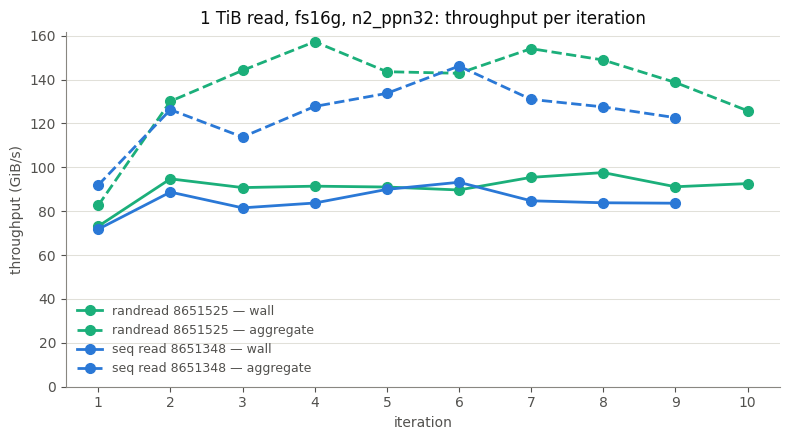

randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525: cold 73.13 GiB/s, warm (iter 2+) mean 92.69 ± 2.63 GiB/s (min 89.66, max 97.59)
read_1tib_n2_ppn32_bs2m_iod16_8651348: cold 71.79 GiB/s, warm (iter 2+) mean 86.15 ± 3.99 GiB/s (min 81.51, max 93.18)


In [3]:
# multi-iteration jobs -> {job: {iter tag: aggregates}}
fs16g_multi = defaultdict(dict)
for (job, it), a in fs16g_pass_agg.items():
    fs16g_multi[job][it] = a
fs16g_multi = {job: iters for job, iters in fs16g_multi.items() if len(iters) > 1}

fig, ax = plt.subplots(figsize=(8, 4.5))
for job, iters in sorted(fs16g_multi.items()):
    pat, jobid = fs16g_jobs[job]["pattern"], fs16g_jobs[job]["jobid"]
    xs = sorted(iters)
    xi = [int(it) for it in xs]
    for metric in ("wall", "aggr"):
        ax.plot(xi, [iters[it][metric] for it in xs], METRIC_STYLE[metric],
                color=PATTERN_COLOR[pat], marker="o", markersize=7, linewidth=2,
                label=f"{PATTERN_NAME[pat]} {jobid} \u2014 {METRIC_NAME[metric]}")

ax.set_xticks(sorted({int(it) for iters in fs16g_multi.values() for it in iters}))
ax.set_ylim(bottom=0)
ax.set_xlabel("iteration", color=INK2)
ax.set_ylabel("throughput (GiB/s)", color=INK2)
ax.set_title("1 TiB read, fs16g, n2_ppn32: throughput per iteration", color=INK)
ax.legend(frameon=False, labelcolor=INK2, fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

for job, iters in sorted(fs16g_multi.items()):
    w = [iters[it]["wall"] for it in sorted(iters)]
    warm = w[1:]
    print(f"{job}: cold {w[0]:.2f} GiB/s, warm (iter 2+) "
          f"mean {st.mean(warm):.2f} \u00b1 {st.stdev(warm):.2f} GiB/s "
          f"(min {min(warm):.2f}, max {max(warm):.2f})")

### Cold/warm observations

Both repeated jobs show a clear cold-to-warm transition:

1. **Iteration 1 is distinctly slower.** Wall bandwidth jumps ~15-25% after the
   first pass (seq read: 71.8 GiB/s cold vs ~86 GiB/s warm mean; randread:
   73.1 vs ~93 GiB/s). The cold values also match the independent
   single-cold-pass jobs at the same n2_ppn32 layout (73.8 and 72.5 GiB/s),
   confirming iteration 1 is genuinely the cold-cache state rather than
   run-to-run noise.
2. **The aggregate metric amplifies the effect.** Sum-of-rank bandwidth rises
   from ~82-92 GiB/s cold to ~125-157 GiB/s warm (+50-70%): once caches are
   warm, many ranks finish their 16 GiB very fast and inflate the sum (min
   rank runtime drops from ~8.4 s to ~3 s), while the wall metric stays
   bounded by the slowest rank and only gains ~20%.
3. **One step, then steady state.** All the warming happens between
   iterations 1 and 2; iterations 2+ just fluctuate with no trend (seq read
   wall 81.5-93.2, stdev ~3.9; randread 89.7-97.6, stdev ~2.6). A single pass
   over the 1 TiB dataset is enough to warm the caches.

This is why the layout sweep in 1.3 below uses only the first iteration: mixing warm
passes in would inflate n2_ppn32 relative to configurations that only have
cold runs.

## 1.3 Throughput vs n x ppn layout

For every job the **first iteration** is used (`iter01`, or the untagged pass) —
the cold pass, before page/DAOS caches warm up. Where a configuration
(pattern x layout) has multiple jobs, the **median** across jobs is plotted.

In [4]:
hdr = f"{'job':<54} {'iter':>4} {'wall GiB/s':>11} {'aggr GiB/s':>11}"
print(hdr); print("-" * len(hdr))
for job, (it, a) in sorted(fs16g_first.items()):
    print(f"{job:<54} {it:>4} {a['wall']:>11.2f} {a['aggr']:>11.2f}")

# Median across jobs per (pattern, layout)
fs16g_sweep = defaultdict(list)
for job, (it, a) in fs16g_first.items():
    p = fs16g_jobs[job]
    fs16g_sweep[(p["pattern"], (int(p["nodes"]), int(p["ppn"])))].append(a)

fs16g_layouts = sorted({lay for (_, lay) in fs16g_sweep})
fs16g_median = {key: {m: st.median(a[m] for a in runs) for m in ("wall", "aggr")}
                for key, runs in fs16g_sweep.items()}

# Run-to-run variability across qsub jobs of the same config (first
# iterations only): peak-to-peak spread relative to the median,
# (max - min) / median.
fs16g_variability = {
    key: {m: (max(a[m] for a in runs) - min(a[m] for a in runs))
             / st.median(a[m] for a in runs)
         for m in ("wall", "aggr")}
    for key, runs in fs16g_sweep.items()
}

hdr = (f"{'pattern':>8} {'layout':>10} {'jobs':>4} {'wall GiB/s':>11} {'aggr GiB/s':>11} "
       f"{'wall var %':>10} {'aggr var %':>10}")
print("\nmedian of first iterations (var = (max-min)/median across jobs):")
print(hdr); print("-" * len(hdr))
for (pat, (n, ppn)), med in sorted(fs16g_median.items()):
    njobs = len(fs16g_sweep[(pat, (n, ppn))])
    v = fs16g_variability[(pat, (n, ppn))]
    print(f"{pat:>8} {f'n{n}_ppn{ppn}':>10} {njobs:>4} "
          f"{med['wall']:>11.2f} {med['aggr']:>11.2f} "
          f"{v['wall']*100:>10.2f} {v['aggr']*100:>10.2f}")

job                                                    iter  wall GiB/s  aggr GiB/s
-----------------------------------------------------------------------------------
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495      01      457.35      464.59
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663501      01      457.55      464.01
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8651525      01       73.13       82.63
randread_fio-1tib-fs16g_n2_ppn32_bs2m_iod16_8660443      01       72.49       80.00
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660091      01      131.60      194.83
randread_fio-1tib-fs16g_n4_ppn16_bs2m_iod16_8660132      01      140.33      187.98
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660298       01      243.17      271.10
randread_fio-1tib-fs16g_n8_ppn8_bs2m_iod16_8660372       01      293.75      314.71
read_1tib_n2_ppn32_bs2m_iod16_8650075                     -       73.82       84.41
read_1tib_n2_ppn32_bs2m_iod16_8651348                    01       71.79     

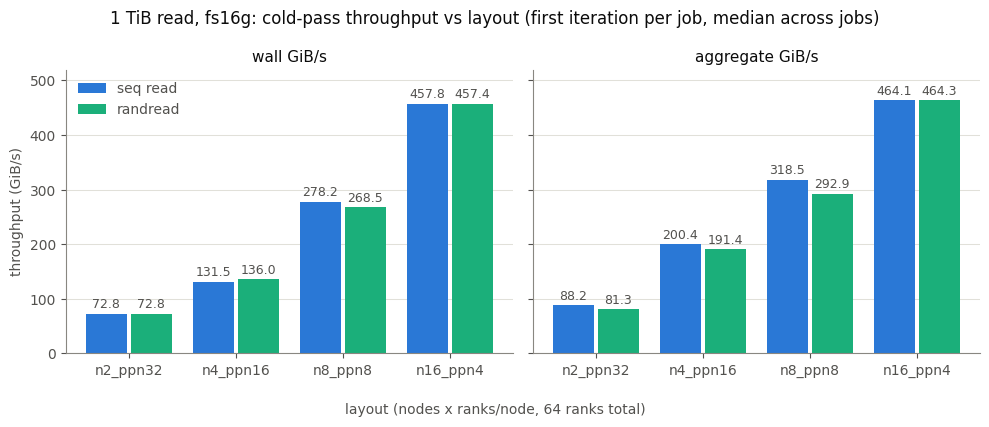

In [5]:
xlabels = [f"n{n}_ppn{ppn}" for n, ppn in fs16g_layouts]
x = range(len(fs16g_layouts))
BAR_W, BAR_GAP = 0.38, 0.04

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, metric in zip(axes, ("wall", "aggr")):
    for k, pat in enumerate(("read", "randread")):
        vals = [fs16g_median[(pat, lay)][metric] for lay in fs16g_layouts]
        pos = [i + (k - 0.5) * (BAR_W + BAR_GAP) for i in x]
        bars = ax.bar(pos, vals, width=BAR_W, color=PATTERN_COLOR[pat],
                      label=PATTERN_NAME[pat])
        ax.bar_label(bars, fmt="%.1f", color=INK2, fontsize=9, padding=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels)
    ax.set_title(f"{METRIC_NAME[metric]} GiB/s", color=INK, fontsize=11)
    style_ax(ax)

ymax = max(med[m] for med in fs16g_median.values() for m in ("wall", "aggr"))
axes[0].set_ylim(0, ymax * 1.12)   # headroom for the value labels
axes[0].set_ylabel("throughput (GiB/s)", color=INK2)
axes[0].legend(frameon=False, labelcolor=INK2)
fig.supxlabel("layout (nodes x ranks/node, 64 ranks total)", color=INK2, fontsize=10)
fig.suptitle("1 TiB read, fs16g: cold-pass throughput vs layout "
             "(first iteration per job, median across jobs)", color=INK)
plt.tight_layout()
plt.show()

## 1.4 Per-rank bandwidth by host

Per-rank bandwidth grouped by compute node, for every job whose node count is
in `BYHOST_NODES` (currently the n8_ppn8 jobs; the upcoming n16_ppn4 jobs are
picked up automatically once their folders appear). First/cold iteration of
each job.

**Rank-to-host mapping:**

- *Runs after 2026-07-10* embed the short hostname in each rank's output
  filename (`..._rankNNN_<hostname>.json`) and are grouped by that hostname.
- *Older runs* have no hostname anywhere (nothing in the fio JSON, no PBS logs
  in this repo), so the mapping falls back to PALS default block placement:
  the launcher runs plain `mpiexec -np 64 -ppn <PPN>` with no placement
  options, so consecutive ranks fill a node before moving to the next and
  **host slot = rank // ppn**. Slots are per-job — slot 3 in one job is
  generally a *different physical node* than slot 3 in another job.

In [8]:
# Group each job's first-pass ranks by host. New runs carry the short
# hostname in the filename; older runs fall back to the block-placement
# slot rank // ppn (see the markdown above).
BYHOST_NODES = {16}   # n8_ppn8 now; auto-includes the n16_ppn4 jobs later

BYHOST_FILE_RE = re.compile(r"rank(?P<rank>\d+)(?:_(?P<host>[^.]+))?\.json$")

fs16g_byhost = {}   # job -> {host label: [(rank, bw GiB/s, runtime s), ...]}
for job, p in sorted(fs16g_jobs.items()):
    if int(p["nodes"]) not in BYHOST_NODES:
        continue
    ppn = int(p["ppn"])
    hosts = defaultdict(list)
    for fp in fs16g_passes[(job, fs16g_first[job][0])]:
        m = BYHOST_FILE_RE.search(fp.name)
        r = int(m["rank"])
        _, bw_b, rt_ms = fs16g_rank[fp]
        hosts[m["host"] or f"slot {r // ppn}"].append((r, bw_b / GiB, rt_ms / 1000))
    # block placement: order hosts by their lowest rank
    fs16g_byhost[job] = dict(sorted(hosts.items(),
                                    key=lambda kv: min(r for r, _, _ in kv[1])))

hdr = (f"{'job':<50} {'host':>14} {'ranks':>7} {'sum bw':>7} "
       f"{'min':>6} {'med':>6} {'max':>6} {'wall s':>6}")
print(hdr); print("-" * len(hdr))
for job, hosts in fs16g_byhost.items():
    for h, rows in hosts.items():
        bws = [bw for _, bw, _ in rows]
        r0, r1 = min(r for r, _, _ in rows), max(r for r, _, _ in rows)
        print(f"{job:<50} {h:>14} {f'{r0}-{r1}':>7} {sum(bws):>7.1f} "
              f"{min(bws):>6.2f} {st.median(bws):>6.2f} {max(bws):>6.2f} "
              f"{max(rt for _, _, rt in rows):>6.2f}")
    walls = {h: max(rt for _, _, rt in rows) for h, rows in hosts.items()}
    slow = max(walls, key=walls.get)
    print(f"  -> slowest host: {slow} ({walls[slow]:.2f} s bounds the wall metric)\n")

job                                                          host   ranks  sum bw    min    med    max wall s
-------------------------------------------------------------------------------------------------------------
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4602c6s7b0n0     0-3    29.1   7.23   7.27   7.31   2.21
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4008c4s3b0n0     4-7    29.2   7.21   7.30   7.35   2.22
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4603c3s7b0n0    8-11    29.0   7.21   7.26   7.30   2.22
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4607c3s4b0n0   12-15    28.9   7.19   7.23   7.28   2.23
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4607c5s7b0n0   16-19    29.0   7.18   7.24   7.30   2.23
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4101c2s0b0n0   20-23    29.1   7.23   7.30   7.31   2.21
randread_fio-1tib-fs16g_n16_ppn4_bs2m_iod16_8663495  x4103c1s2b0n0   24-27    29.0   7.22   7.25   7.33   2.22
ran

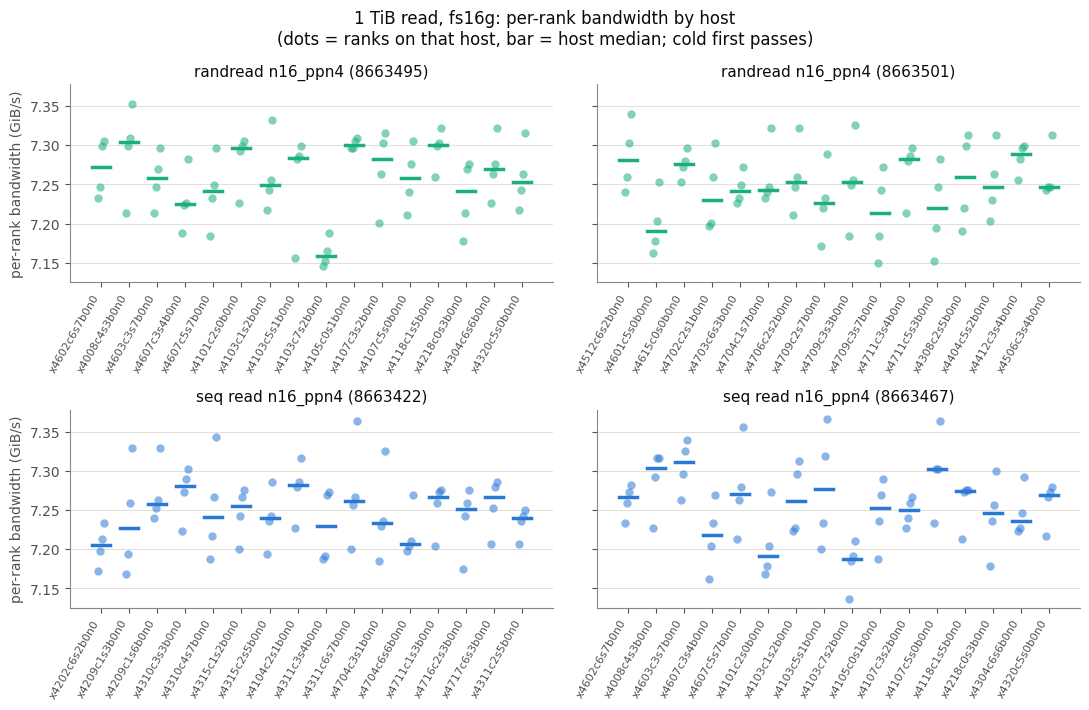

In [9]:
# One panel per job: one dot per rank on that host (sorted by value, spread
# for visibility) and a horizontal bar at the host median. The panel grid
# adapts to however many jobs BYHOST_NODES matches.
ncols = 2
nrows = -(-len(fs16g_byhost) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.6 * nrows), sharey=True)
axes = list(axes.flat)
for ax in axes[len(fs16g_byhost):]:
    ax.set_visible(False)

for i, (ax, (job, hosts)) in enumerate(zip(axes, fs16g_byhost.items())):
    p = fs16g_jobs[job]
    c = PATTERN_COLOR[p["pattern"]]
    spread = min(0.07, 0.7 / max(len(rows) for rows in hosts.values()))
    for hx, rows in enumerate(hosts.values()):
        bws = sorted(bw for _, bw, _ in rows)
        xs = [hx + (k - (len(bws) - 1) / 2) * spread for k in range(len(bws))]
        ax.plot(xs, bws, "o", markersize=6, color=c, alpha=0.55, markeredgewidth=0)
        ax.plot([hx - 0.32, hx + 0.32], [st.median(bws)] * 2, color=c, linewidth=2.5)
    labels = list(hosts)
    rot = 60 if max(map(len, labels)) > 8 else 0
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8, rotation=rot,
                       ha="right" if rot else "center")
    ax.set_title(f"{PATTERN_NAME[p['pattern']]} n{p['nodes']}_ppn{p['ppn']} "
                 f"({p['jobid']})", color=INK, fontsize=11)
    if i % ncols == 0:
        ax.set_ylabel("per-rank bandwidth (GiB/s)", color=INK2)
    style_ax(ax)

fig.suptitle("1 TiB read, fs16g: per-rank bandwidth by host\n"
             "(dots = ranks on that host, bar = host median; cold first passes)",
             color=INK)
plt.tight_layout()
plt.show()